# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [4]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0.03,  
    'close_confidence': 0.2,  
    'standard_num': 1000,
    'trailing_stop_pct': 0.001,
    'max_pct': 0.004,
    'min_pct': 0.001,

    'k_pct': 1,
    'k_up': 3,
    'k_down': 3,
    
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [5]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

train_dates, valid_dates, test_dates = split_dates(trade_dates,35,9,10)

总交易日数量: 54
交易日范围: 20260105 ~ 20260327
训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260313 (9天)
测试集: 20260316 ~ 20260327 (10天)


## 生成训练数据

In [6]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
训练集样本: X=(27632, 13), y=(27632,)
标签分布:
0    19665
1     7967
Name: count, dtype: int64


In [7]:
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260303: 产生 794 个样本
20260304: 产生 886 个样本
20260305: 产生 807 个样本
20260306: 产生 780 个样本
20260309: 产生 804 个样本
20260310: 产生 783 个样本
20260311: 产生 763 个样本
20260312: 产生 759 个样本
20260313: 产生 750 个样本
验证集样本: X=(7126, 13), y=(7126,)
标签分布:
0    4995
1    2131
Name: count, dtype: int64


In [8]:
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")
if len(y_test) > 0:
    print(f"标签分布:\n{y_test.value_counts()}")

生成测试集样本...
20260316: 产生 755 个样本
20260317: 产生 762 个样本
20260318: 产生 795 个样本
20260319: 产生 792 个样本
20260320: 产生 815 个样本
20260323: 产生 844 个样本
20260324: 产生 842 个样本
20260325: 产生 783 个样本
20260326: 产生 862 个样本
20260327: 产生 787 个样本
测试集样本: X=(8037, 13), y=(8037,)
标签分布:
0    5659
1    2378
Name: count, dtype: int64


## 训练模型

In [9]:

model = train_model(X_train, y_train, X_valid, y_valid, param_dict)

训练 xgboost 模型...
阈值优化完成: Best Threshold=0.3721, F0.5=0.4433

特征重要性（前10个）:
volatility    0.215927
alpha_04      0.094011
WAMP          0.083582
spread        0.082144
best_ask      0.081504
num_trades    0.077477
best_bid      0.076379
alpha_05      0.053695
alpha_02      0.052314
alpha_01      0.049807
dtype: float32


## 测试模型

测试集准确率: 0.6558

分类报告:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      5659
           1       0.43      0.46      0.44      2378

    accuracy                           0.66      8037
   macro avg       0.60      0.60      0.60      8037
weighted avg       0.67      0.66      0.66      8037


PR曲线AUC: 0.4287
平均精度 (AP): 0.4292

预测概率统计:
  均值: 0.2745
  标准差: 0.1894
  最小值: 0.0033
  25%分位数: 0.1003
  中位数: 0.2483
  75%分位数: 0.4256
  最大值: 0.8324

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.2451, 标准差=0.1799
  标签1 (正类): 均值=0.3445, 标准差=0.1930


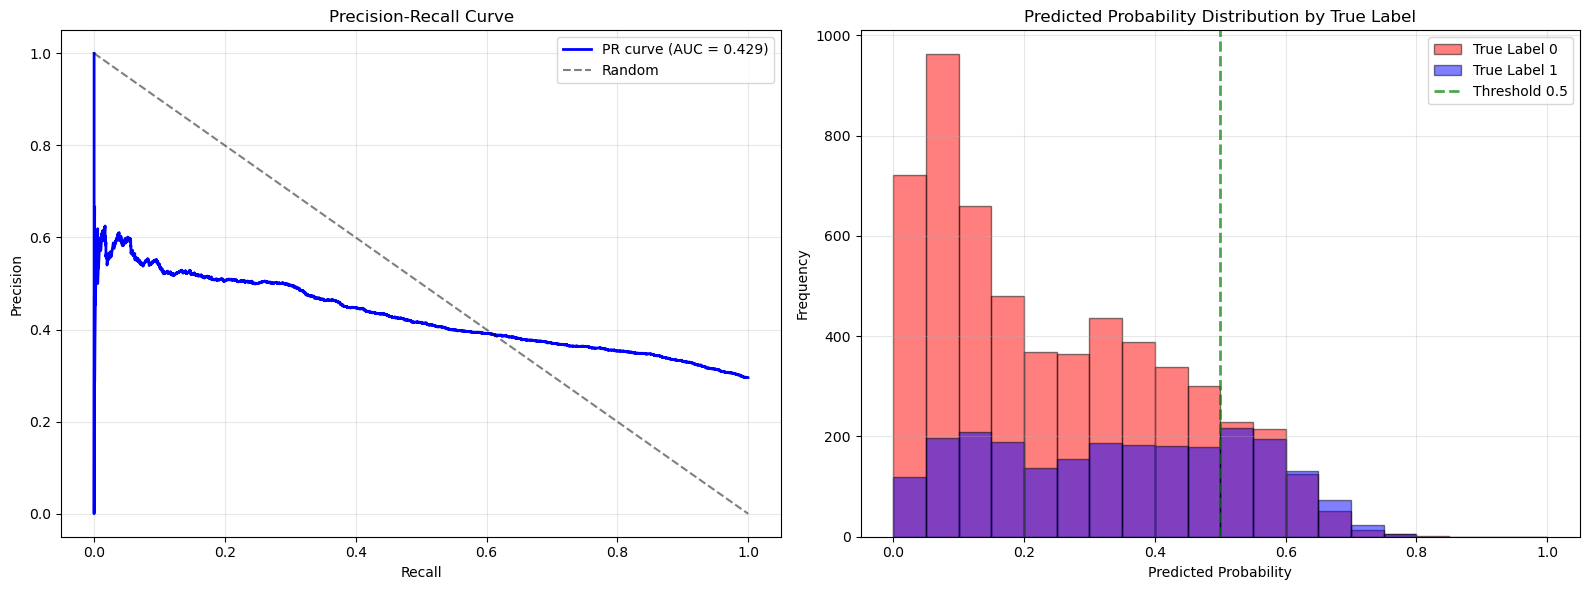

In [10]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

测试集准确率: 0.6700

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77      5659
           1       0.44      0.43      0.44      2378

    accuracy                           0.67      8037
   macro avg       0.60      0.60      0.60      8037
weighted avg       0.67      0.67      0.67      8037

## 创建策略实例

In [11]:
strategy = StrategyDemo(model, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

In [12]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from multi_day_backtest import backtest_multi_days, backtest_summary
from delta.strategy import StrategyDemo

result_df = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd='20260303',
    end_ymd='20260330',
    StrategyClass= StrategyDemo,
    model = model,
    param_dict=param_dict,
    official = False
)

summary = backtest_summary(result_df)
print(summary)

日期 20260303 完成，盈亏: 13.60, 成交: 15次


KeyboardInterrupt: 

In [37]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(result_df)

,trade_ymd,profits,trades,trade_date
0,20260303,13.3,16,2026-03-03
1,20260304,6.0,22,2026-03-04
2,20260305,-6.1,19,2026-03-05
3,20260306,-0.4,11,2026-03-06
4,20260309,3.9,17,2026-03-09
5,20260310,-3.6,10,2026-03-10
6,20260311,5.6,8,2026-03-11
7,20260312,0.7,10,2026-03-12
8,20260313,0.6,10,2026-03-13
9,20260316,-0.4,13,2026-03-16


## 保存回测结果

In [ ]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果
result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260413_025020
回测结果已保存到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260413_025020
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [ ]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260408", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260408", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹

总共删除了 0 个文件夹


## 单日回测观察

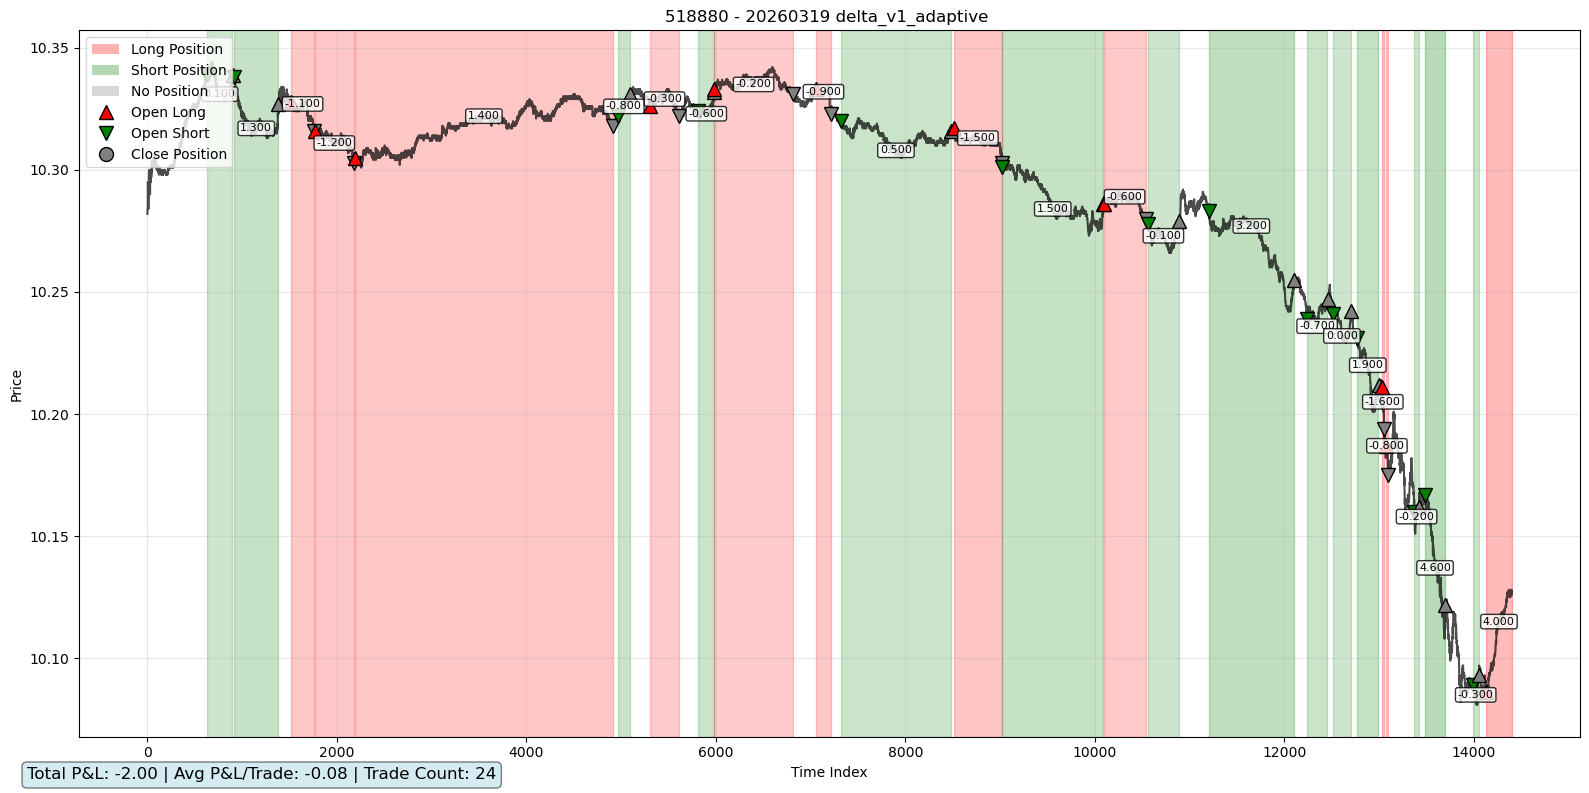

In [15]:
from single_day_backtest import single_day_backtest
hh = single_day_backtest(instrument_id,'20260319',StrategyDemo,model,param_dict,official = False)